In [1]:
# =========================
# IMPROVED KNN MODEL
# =========================

import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# =========================
# LOAD CLEANED DATASET
# =========================

import pandas as pd

df = pd.read_csv("cleaned_gas_monitoring.csv")

print("Cleaned dataset loaded successfully.")
display(df.head())
print(df.shape)

Cleaned dataset loaded successfully.


,TIME_OF_DAY,TEMPERATURE,HUMIDITY,CO2_INFRAREDSENSOR,CO2_ELECTROCHEMICALSENSOR,METALOXIDESENSOR_UNIT1,METALOXIDESENSOR_UNIT2,METALOXIDESENSOR_UNIT3,METALOXIDESENSOR_UNIT4,CO_GASSENSOR,SESSION_ID,HVAC_OPERATION_MODE,AMBIENT_LIGHT_LEVEL,ACTIVITY_LEVEL
0,morning,19.63,53.83,125.49,571.09,478.55,735.85,654.63,565.05,2.0,7241,off,very dim,low activity
1,morning,19.62,54.25,126.56,585.54,505.56,737.11,649.96,558.07,1.0,7241,eco mode,very bright,low activity
2,morning,20.10,50.48,113.50,597.45,515.14,744.02,676.15,600.22,1.0,7241,eco mode,very bright,high activity
3,morning,19.89,48.42,92.77,613.65,535.66,770.27,720.27,625.73,1.0,7241,heating active,moderate,low activity
4,night,20.04,48.42,118.29,582.62,474.78,736.89,694.94,628.88,1.0,6431,heating active,bright,low activity


(6381, 14)


In [3]:
# =========================
# PREPARE FEATURES AND TARGET
# =========================

y = df["ACTIVITY_LEVEL"]

X = df.drop(columns=["ACTIVITY_LEVEL", "SESSION_ID"])

# CO_GASSENSOR values are 1-4, so treat it as a category instead of continuous number
X["CO_GASSENSOR"] = X["CO_GASSENSOR"].astype(str)

print("Features used:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features used:
Index(['TIME_OF_DAY', 'TEMPERATURE', 'HUMIDITY', 'CO2_INFRAREDSENSOR',
       'CO2_ELECTROCHEMICALSENSOR', 'METALOXIDESENSOR_UNIT1',
       'METALOXIDESENSOR_UNIT2', 'METALOXIDESENSOR_UNIT3',
       'METALOXIDESENSOR_UNIT4', 'CO_GASSENSOR', 'HVAC_OPERATION_MODE',
       'AMBIENT_LIGHT_LEVEL'],
      dtype='str')

Target:
ACTIVITY_LEVEL


In [4]:
# =========================
# ENCODE CATEGORICAL COLUMNS
# =========================
# Use drop_first=False for KNN so each category is represented clearly

X = pd.get_dummies(X, drop_first=False)

print("Shape after encoding:")
print(X.shape)

display(X.head())

Shape after encoding:
(6381, 27)


,TEMPERATURE,HUMIDITY,CO2_INFRAREDSENSOR,CO2_ELECTROCHEMICALSENSOR,METALOXIDESENSOR_UNIT1,METALOXIDESENSOR_UNIT2,METALOXIDESENSOR_UNIT3,METALOXIDESENSOR_UNIT4,TIME_OF_DAY_afternoon,TIME_OF_DAY_evening,...,HVAC_OPERATION_MODE_eco mode,HVAC_OPERATION_MODE_heating active,HVAC_OPERATION_MODE_maintenance mode,HVAC_OPERATION_MODE_off,HVAC_OPERATION_MODE_ventilation only,AMBIENT_LIGHT_LEVEL_bright,AMBIENT_LIGHT_LEVEL_dim,AMBIENT_LIGHT_LEVEL_moderate,AMBIENT_LIGHT_LEVEL_very bright,AMBIENT_LIGHT_LEVEL_very dim
0,19.63,53.83,125.49,571.09,478.55,735.85,654.63,565.05,False,False,...,False,False,False,True,False,False,False,False,False,True
1,19.62,54.25,126.56,585.54,505.56,737.11,649.96,558.07,False,False,...,True,False,False,False,False,False,False,False,True,False
2,20.10,50.48,113.50,597.45,515.14,744.02,676.15,600.22,False,False,...,True,False,False,False,False,False,False,False,True,False
3,19.89,48.42,92.77,613.65,535.66,770.27,720.27,625.73,False,False,...,False,True,False,False,False,False,False,True,False,False
4,20.04,48.42,118.29,582.62,474.78,736.89,694.94,628.88,False,False,...,False,True,False,False,False,True,False,False,False,False


In [5]:
# =========================
# TRAIN-TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5104, 27)
Testing set shape: (1277, 27)


In [6]:
# =========================
# TUNE KNN MODEL
# =========================
# This tests different K values, distance weighting, and distance metrics

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(3, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(round(grid_search.best_score_, 4))

Best parameters:
{'knn__n_neighbors': 27, 'knn__p': 1, 'knn__weights': 'distance'}

Best cross-validation accuracy:
0.6452


In [7]:
# =========================
# TEST BEST KNN MODEL
# =========================

best_knn_model = grid_search.best_estimator_

y_pred_knn = best_knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_knn)

print("Improved KNN Accuracy:")
print(round(accuracy, 4))

print("\nImproved KNN Accuracy Percentage:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))     

Improved KNN Accuracy:
0.6578

Improved KNN Accuracy Percentage:
65.78 %

Classification Report:
                   precision    recall  f1-score   support

    high activity       0.47      0.11      0.18       157
     low activity       0.73      0.83      0.77       735
moderate activity       0.53      0.55      0.54       385

         accuracy                           0.66      1277
        macro avg       0.58      0.50      0.50      1277
     weighted avg       0.64      0.66      0.63      1277


Confusion Matrix:
[[ 18  69  70]
 [  8 610 117]
 [ 12 161 212]]


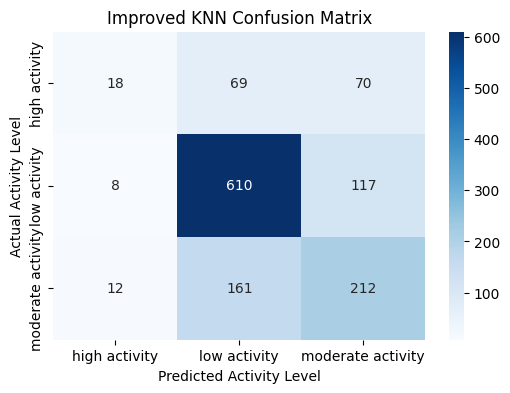

In [8]:
# =========================
# CONFUSION MATRIX HEATMAP
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_knn_model.classes_,
    yticklabels=best_knn_model.classes_
)

plt.title("Improved KNN Confusion Matrix")
plt.xlabel("Predicted Activity Level")
plt.ylabel("Actual Activity Level")
plt.show()